# Projeto end-to-end com modelos baseados em árvores
## Priorização de clientes em uma campanha bancária

Este notebook transforma o Capítulo 8 de *An Introduction to Statistical Learning with Applications in Python* em um projeto de ciência de dados completo. O problema é decidir **quais clientes devem ser contatados primeiro** em uma campanha de depósito a prazo, antes de a ligação acontecer.

O fio condutor combina:

1. árvore de classificação, poda, bagging, random forest, boosting e a discussão de BART do ISLP;
2. formulação do problema, separação do teste, pipelines, avaliação e persistência do *Hands-On Machine Learning*;
3. baselines, validação cruzada, inspeção e boas práticas do curso de scikit-learn da Inria;
4. análise de vazamento, custos, capacidade operacional, drift e contrato de dados de um projeto real.

O objetivo não é perseguir o maior número possível. O objetivo é aprender a justificar cada decisão e reconhecer quando uma métrica deixa de representar o uso comercial.

> **Execução autônoma:** o CSV da UCI está compactado dentro do notebook. Não há download obrigatório.

## O que você deverá saber ao terminar

Você deverá conseguir explicar:

- como uma árvore constrói regiões por divisões binárias;
- por que uma árvore profunda tende a apresentar alta variância;
- como a poda por complexidade de custo controla o tamanho da árvore;
- o que o bootstrap muda no bagging e por que o random forest sorteia atributos;
- como boosting corrige erros de forma sequencial;
- por que acurácia e `oob_score_` podem ser pouco informativos em uma classe rara;
- como detectar uma variável disponível tarde demais, mesmo que ela seja muito preditiva;
- como escolher um modelo antes de abrir o teste futuro;
- como traduzir probabilidades em uma fila de contatos com capacidade limitada;
- o que deve ser salvo no pickle para que treino e inferência usem a mesma engenharia de atributos.

## Mapa do projeto

| Grande bloco | Pergunta técnica | Pergunta comercial | Evidência produzida |
| --- | --- | --- | --- |
| Formulação | Qual é o alvo e quando os atributos existem? | Qual decisão será apoiada? | contrato do problema e auditoria de vazamento |
| Dados | A amostra muda no tempo? | A campanha futura se parece com o histórico? | análise temporal e drift de prevalência |
| Árvore | Qual complexidade generaliza? | Uma regra simples é suficiente? | árvore rasa e caminho de poda |
| Ensembles | A redução de variância ou de viés ajuda mais? | O ganho compensa custo e opacidade? | validação temporal comparativa |
| Teste futuro | O ranqueamento e as probabilidades resistem ao tempo? | Quantas adesões cabem na capacidade? | AP, AUC, calibração, lift e lucro simulado |
| Operação | O mesmo pré-processamento chega à produção? | Como falhas e mudanças serão monitoradas? | pickle, contrato de entrada e PSI |

## 0. Formulação do problema antes do código

**Unidade de análise:** um contato de campanha associado a um cliente.

**Momento da previsão:** antes de iniciar a ligação da campanha atual.

**Alvo:** `y = yes` quando o cliente assina um depósito a prazo.

**Saída:** um escore de propensão usado para ordenar a fila de contatos.

**Ação simulada:** contatar os 20% de clientes com maior escore, pois a equipe tem capacidade limitada.

**Métrica primária de seleção:** average precision (AP). Ela resume a curva precisão-recall e é apropriada quando a classe positiva é minoritária.

**Métricas de apoio:** ROC AUC para ordenação global, log loss e Brier para probabilidades, além de precisão, recall e lift na capacidade de 20%.

**Hipótese comercial apenas para ensino:** cada adesão observada vale €200 e cada ligação custa €10. Esses valores não vêm da instituição e não devem ser usados em uma decisão real.

### Pergunta profunda 1

Por que o alvo deve ser descrito junto com o instante da decisão?

<details>
<summary>Resposta guiada</summary>

Uma coluna pode existir na base histórica e ainda ser impossível de conhecer no instante de uso. Sem o momento da decisão, uma variável posterior pode entrar no treinamento, inflar as métricas e criar um sistema que não pode operar.

</details>

## 1. Fundamentos do Capítulo 8

### 1.1 Divisão binária recursiva

Uma árvore de classificação procura um atributo $j$ e um ponto de corte $s$ que formem duas regiões:

$$R_1(j,s)=\{X\mid X_j<s\}, \qquad R_2(j,s)=\{X\mid X_j\geq s\}.$$

Para duas classes, a impureza de Gini do nó $m$ é:

$$G_m=\sum_{k=1}^{K}\hat p_{mk}(1-\hat p_{mk}).$$

O algoritmo escolhe a divisão que mais reduz a impureza ponderada. O processo é guloso: a melhor decisão local não garante a melhor árvore global.

**Leitura técnica:** uma árvore aprende limiares, interações e relações não lineares sem especificá-los antecipadamente.

**Leitura comercial:** as regras são fáceis de inspecionar, mas uma regra aprendida em uma campanha pode ser instável quando o perfil de clientes muda.

### 1.2 Poda por complexidade de custo

Uma árvore totalmente crescida costuma memorizar particularidades. A poda escolhe uma subárvore $T$ minimizando:

$$R_\alpha(T)=R(T)+\alpha|T|,$$

em que $R(T)$ mede o erro ou impureza e $|T|$ é o número de folhas. Quanto maior `ccp_alpha`, maior a penalização por complexidade.

O valor de `ccp_alpha` não será escolhido pelo desempenho de treino. Ele será validado em blocos temporais anteriores ao teste.

### Pergunta profunda 2

Uma árvore menor sempre é mais interpretável?

<details>
<summary>Resposta guiada</summary>

Uma árvore pequena facilita a leitura de suas regras. A interpretação ainda depende da qualidade dos atributos, da estabilidade dos cortes e do uso pretendido. Uma regra curta baseada em uma variável com vazamento continua sendo inválida.

</details>

### 1.3 Bagging, random forest e boosting

No **bagging**, ajustamos árvores em amostras bootstrap e agregamos suas probabilidades:

$$\hat f_{bag}(x)=\frac{1}{B}\sum_{b=1}^{B}\hat f^{*b}(x).$$

A média reduz a variância quando os erros das árvores não são perfeitamente correlacionados.

O **random forest** adiciona diversidade ao considerar apenas um subconjunto aleatório de atributos em cada divisão. A redução da correlação pode melhorar a generalização.

No **gradient boosting**, as árvores são adicionadas em sequência. Cada nova árvore procura reduzir a perda deixada pelo conjunto atual. A taxa de aprendizagem controla o tamanho de cada correção.

| Método | Construção | Problema que tenta reduzir | Cuidado principal |
| --- | --- | --- | --- |
| Bagging | árvores independentes em bootstrap | variância | árvores correlacionadas reduzem o ganho |
| Random forest | bagging e sorteio de atributos | variância e correlação | importância por impureza pode ser enviesada |
| Boosting | árvores sequenciais e rasas | viés residual | taxa alta e muitas iterações podem sobreajustar |

### BART em uma frase

O Bayesian Additive Regression Trees combina muitas árvores pequenas sob uma distribuição posterior. Ele permite quantificar incerteza posterior, mas exige escolhas de prior, amostragem e diagnóstico. Este projeto registra BART como extensão conceitual e concentra o benchmark em estimadores da API estável do scikit-learn, para manter a execução autônoma e comparar as ideias centrais com a mesma infraestrutura.

## 2. Ambiente e reprodutibilidade

O pipeline será o objeto central. Ele garante que categorias, medianas, faixas e modelo sejam ajustados dentro de cada fold. Isso evita que o pré-processamento aprenda informações do futuro.

In [1]:
# Biblioteca padrão
import base64
import gzip
import hashlib
import io
import json
import platform
import sys
import time
import warnings
from pathlib import Path

# Análise e visualização
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

# Modelagem
from sklearn import __version__ as sklearn_version
from sklearn.base import clone
from sklearn.calibration import CalibrationDisplay
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import (
    BaggingClassifier,
    HistGradientBoostingClassifier,
    RandomForestClassifier,
)
from sklearn.impute import SimpleImputer
from sklearn.inspection import PartialDependenceDisplay, permutation_importance
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay,
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    log_loss,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import Binarizer, KBinsDiscretizer, OneHotEncoder
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree

SEED = 42
CAPACIDADE = 0.20
VALOR_ADESAO = 200.0
CUSTO_CONTATO = 10.0

np.random.seed(SEED)
warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})
pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

versoes = pd.Series({
    "Python": platform.python_version(),
    "pandas": pd.__version__,
    "NumPy": np.__version__,
    "scikit-learn": sklearn_version,
    "joblib": joblib.__version__,
}, name="versão")
versoes.to_frame()

,versão
Python,3.14.3
pandas,2.3.3
NumPy,2.4.3
scikit-learn,1.8.0
joblib,1.5.3


**Interpretação do bloco:** registrar versões é parte do experimento. Pickles do scikit-learn não têm garantia de compatibilidade entre versões. Em produção, a versão do ambiente deve acompanhar o artefato.

## 3. Carregamento, proveniência e dicionário

O conjunto Bank Marketing contém 45.211 contatos de campanhas telefônicas de uma instituição bancária portuguesa. O objetivo original é prever a assinatura de um depósito a prazo. A UCI informa que `bank-full.csv` está ordenado no tempo.

O arquivo tem 16 entradas e um alvo. A cópia incorporada será validada por forma, nomes e hash antes do uso.

In [2]:
# O CSV está compactado no notebook para eliminar dependência de rede.
DATA_B64 = "..."
raw_bytes = gzip.decompress(base64.b64decode(DATA_B64))
sha256 = hashlib.sha256(raw_bytes).hexdigest()

dados = pd.read_csv(io.BytesIO(raw_bytes), sep=";")
assert dados.shape == (45211, 17)
assert dados.columns[-1] == "y"

print(f"Dimensão: {dados.shape[0]:,} linhas × {dados.shape[1]} colunas")
print(f"SHA-256 da cópia incorporada: {sha256}")
dados.head()

Dimensão: 45,211 linhas × 17 colunas
SHA-256 da cópia incorporada: 4160f71e33cd6436836304ef6dac88b3cbddaba9d23e48c1a6662a751b8de47e


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [3]:
dicionario = pd.DataFrame({
    "grupo": [
        "cliente", "cliente", "cliente", "cliente", "cliente", "cliente", "cliente", "cliente",
        "campanha atual", "campanha atual", "campanha atual", "campanha atual", "campanha atual",
        "campanha anterior", "campanha anterior", "campanha anterior", "alvo",
    ],
    "variavel": dados.columns,
    "significado": [
        "idade", "ocupação", "estado civil", "escolaridade", "inadimplência de crédito",
        "saldo anual médio em euros", "empréstimo habitacional", "empréstimo pessoal",
        "meio de contato", "dia do último contato", "mês do último contato",
        "duração do último contato em segundos", "número de contatos na campanha",
        "dias desde contato anterior; -1 significa nunca", "contatos antes da campanha",
        "resultado da campanha anterior", "assinou depósito a prazo",
    ],
    "disponivel_antes_da_ligacao": [
        True, True, True, True, True, True, True, True,
        True, True, True, False, True, True, True, True, False,
    ],
})
dicionario

,grupo,variavel,significado,disponivel_antes_da_ligacao
0,cliente,age,idade,True
1,cliente,job,ocupação,True
2,cliente,marital,estado civil,True
3,cliente,education,escolaridade,True
4,cliente,default,inadimplência de crédito,True
5,cliente,balance,saldo anual médio em euros,True
6,cliente,housing,empréstimo habitacional,True
7,cliente,loan,empréstimo pessoal,True
8,campanha atual,contact,meio de contato,True
9,campanha atual,day,dia do último contato,True


### Decisão técnica e comercial

`duration` é a duração da ligação atual. Ela só existe quando a ligação termina. Um modelo usado para priorizar contatos precisa tomar a decisão antes desse momento, então a coluna será excluída.

`day`, `month`, `contact` e `campaign` são mantidos sob a hipótese de que o planejamento já definiu o período, o canal e o número de tentativas. Se o uso real ocorrer antes dessas definições, o contrato deverá ser revisto e essas colunas também podem se tornar vazamento.

## 4. Auditoria inicial e leitura temporal

Exploração será feita antes do teste, mas sem usar o teste para escolher o modelo. A divisão respeita a ordem do arquivo: 80% iniciais para desenvolvimento e 20% finais para uma simulação de futuro.

In [4]:
# O alvo é convertido para 0/1, mantendo a ordem original.
y = dados["y"].eq("yes").astype("int8")
X_com_duration = dados.drop(columns="y")
X = X_com_duration.drop(columns="duration")

n_treino = int(len(dados) * 0.80)
X_train = X.iloc[:n_treino].copy()
X_test = X.iloc[n_treino:].copy()
y_train = y.iloc[:n_treino].copy()
y_test = y.iloc[n_treino:].copy()

resumo_split = pd.DataFrame({
    "linhas": [len(X_train), len(X_test)],
    "taxa_adesao": [y_train.mean(), y_test.mean()],
}, index=["desenvolvimento: 80% iniciais", "teste futuro: 20% finais"])
resumo_split

,linhas,taxa_adesao
desenvolvimento: 80% iniciais,36168,0.0673
teste futuro: 20% finais,9043,0.3158


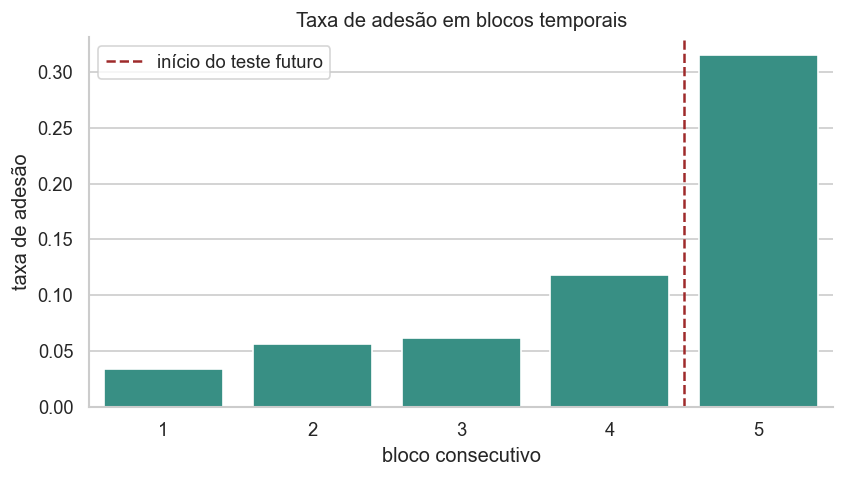

,bloco,linhas,taxa_adesao
0,1,9043,0.0336
1,2,9042,0.0562
2,3,9042,0.0614
3,4,9042,0.1179
4,5,9042,0.3159


In [6]:
# Cinco blocos consecutivos revelam mudança de prevalência ao longo do arquivo.
bloco = pd.qcut(np.arange(len(y)), q=5, labels=["1", "2", "3", "4", "5"])
temporal = (
    pd.DataFrame({"bloco": bloco, "adesao": y})
    .groupby("bloco", observed=True)
    .agg(linhas=("adesao", "size"), taxa_adesao=("adesao", "mean"))
    .reset_index()
)

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=temporal, x="bloco", y="taxa_adesao", color="#2A9D8F", ax=ax)
ax.axvline(3.5, color="#9E2A2B", linestyle="--", label="início do teste futuro")
ax.set(title="Taxa de adesão em blocos temporais", xlabel="bloco consecutivo", ylabel="taxa de adesão")
ax.legend()
plt.show()

display(temporal)

In [7]:
delta_prevalencia = y_test.mean() - y_train.mean()
display(Markdown(f"""
**Leitura do resultado:** a taxa positiva sobe de **{y_train.mean():.1%}** no desenvolvimento para
**{y_test.mean():.1%}** no teste futuro, uma diferença de **{delta_prevalencia:.1%}**.

Isso cria dois desafios. Primeiro, as probabilidades podem ficar descalibradas mesmo quando a ordenação ainda funciona.
Segundo, uma validação aleatória misturaria regimes e produziria uma pergunta mais fácil que a operação real.
"""))


**Leitura do resultado:** a taxa positiva sobe de **6.7%** no desenvolvimento para
**31.6%** no teste futuro, uma diferença de **24.9%**.

Isso cria dois desafios. Primeiro, as probabilidades podem ficar descalibradas mesmo quando a ordenação ainda funciona.
Segundo, uma validação aleatória misturaria regimes e produziria uma pergunta mais fácil que a operação real.


### Pergunta profunda 3

Por que uma prevalência maior no teste não garante AP maior por mérito do modelo?

<details>
<summary>Resposta guiada</summary>

A linha de base da curva precisão-recall é a prevalência. Quando há mais positivos, a AP de um classificador aleatório também aumenta. A AP deve ser lida junto com a taxa positiva, o lift e uma comparação com o baseline do mesmo período.

</details>

In [8]:
# Qualidade estrutural: nulos explícitos, duplicatas e cardinalidade.
qualidade = pd.DataFrame({
    "dtype": X_train.dtypes.astype(str),
    "nulos": X_train.isna().sum(),
    "unicos": X_train.nunique(dropna=False),
}).sort_values(["nulos", "unicos"], ascending=[False, False])

print(f"Duplicatas exatas no desenvolvimento: {X_train.duplicated().sum():,}")
print(f"Valor sentinela pdays=-1: {(X_train['pdays'] == -1).mean():.1%}")
qualidade

Duplicatas exatas no desenvolvimento: 16
Valor sentinela pdays=-1: 89.4%


,dtype,nulos,unicos
balance,int64,0,6656
pdays,int64,0,339
age,int64,0,70
campaign,int64,0,48
previous,int64,0,34
day,int64,0,31
job,object,0,12
month,object,0,11
education,object,0,4
poutcome,object,0,4


**Interpretação:** a ausência formal de `NaN` não significa ausência semântica. `pdays=-1` representa “nunca contatado” e `unknown` representa categoria desconhecida. Ambos carregam significado operacional e serão preservados.

Duplicatas não serão removidas automaticamente. A unidade é contato, e clientes podem aparecer em tentativas diferentes. Sem identificador de cliente, não podemos distinguir repetição legítima de duplicação técnica. Essa limitação deve ser registrada.

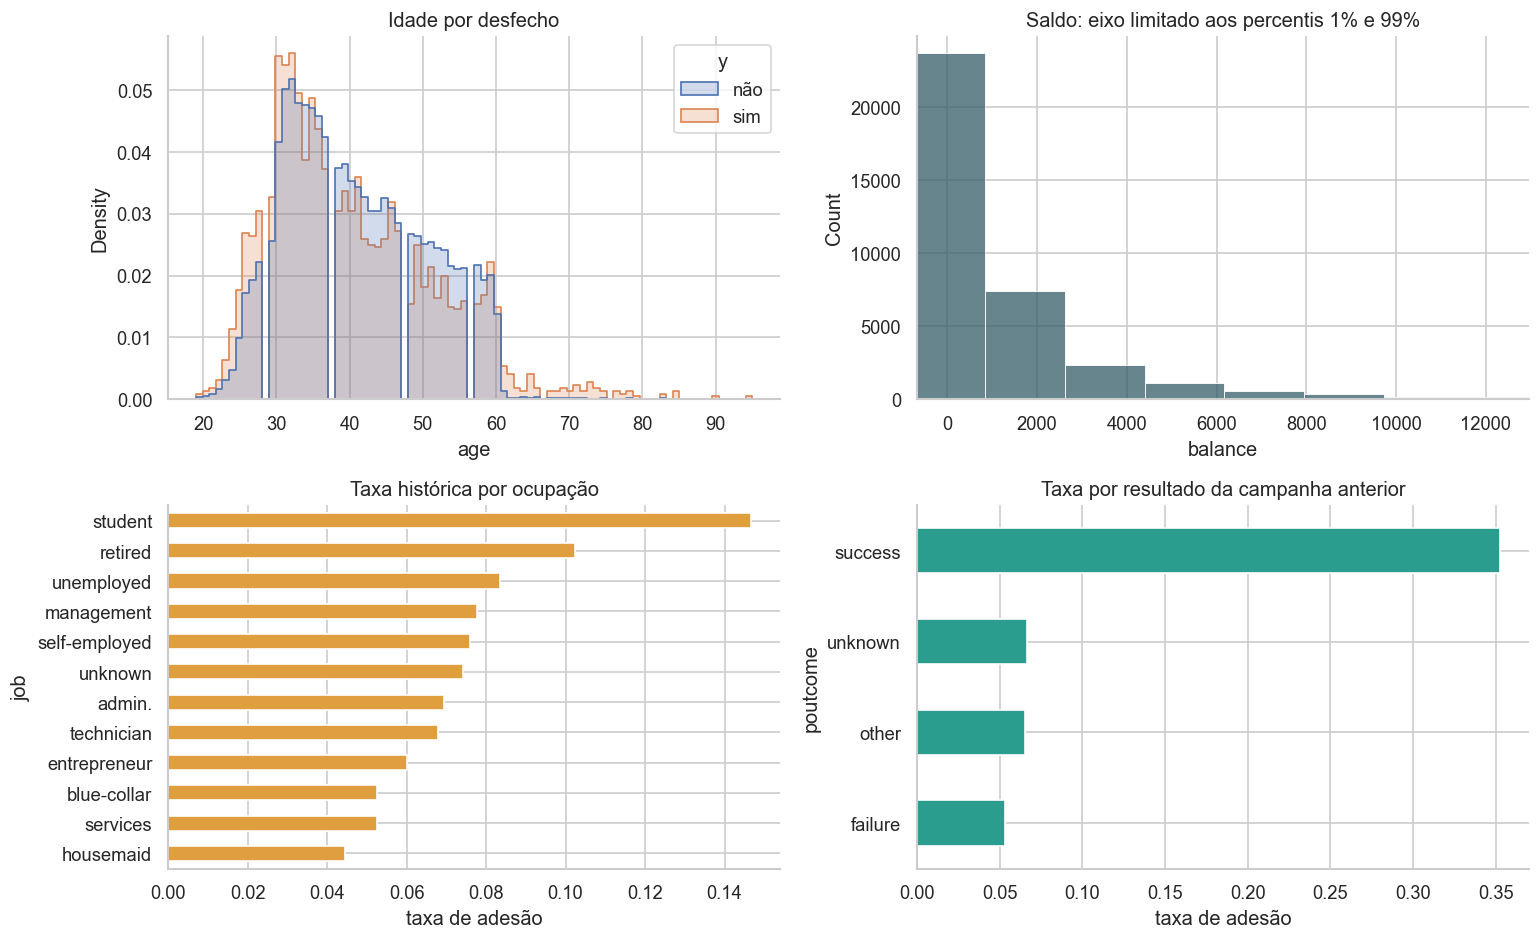

In [9]:
# EDA restrita ao desenvolvimento. O teste continua fechado para seleção.
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

sns.histplot(data=X_train, x="age", hue=y_train.map({0: "não", 1: "sim"}),
             stat="density", common_norm=False, element="step", ax=axes[0, 0])
axes[0, 0].set_title("Idade por desfecho")

sns.histplot(data=X_train, x="balance", bins=60, ax=axes[0, 1], color="#335C67")
axes[0, 1].set_xlim(X_train["balance"].quantile(0.01), X_train["balance"].quantile(0.99))
axes[0, 1].set_title("Saldo: eixo limitado aos percentis 1% e 99%")

job_rate = pd.DataFrame({"job": X_train["job"], "y": y_train}).groupby("job")["y"].agg(["mean", "size"])
job_rate.sort_values("mean").plot.barh(y="mean", legend=False, ax=axes[1, 0], color="#E09F3E")
axes[1, 0].set_title("Taxa histórica por ocupação")
axes[1, 0].set_xlabel("taxa de adesão")

poutcome_rate = pd.DataFrame({"poutcome": X_train["poutcome"], "y": y_train}).groupby("poutcome")["y"].agg(["mean", "size"])
poutcome_rate.sort_values("mean").plot.barh(y="mean", legend=False, ax=axes[1, 1], color="#2A9D8F")
axes[1, 1].set_title("Taxa por resultado da campanha anterior")
axes[1, 1].set_xlabel("taxa de adesão")

plt.tight_layout()
plt.show()

**Leitura técnica:** saldos têm cauda longa, variáveis categóricas apresentam taxas diferentes e o resultado anterior parece informativo. Árvores lidam com limiares e interações, mas podem criar cortes instáveis em categorias raras e extremos.

**Leitura comercial:** uma taxa histórica por ocupação não autoriza uma política discriminatória. Ela pode refletir canal, oferta, horário, seleção prévia ou composição da amostra. A análise é associativa e exige auditoria antes de qualquer uso sobre pessoas.

## 5. Experimento controlado de vazamento

Vamos medir a diferença entre dois cenários:

- **válido:** atributos disponíveis antes da ligação;
- **inválido:** inclui `duration`, conhecida depois da ligação.

O mesmo algoritmo e os mesmos folds temporais serão usados. A diferença observada será atribuída à disponibilidade da coluna, não a uma troca de modelo.

In [10]:
def preprocessor_basico(frame):
    '''Cria transformação simples para um experimento comparável.'''
    cat = frame.select_dtypes(include="object").columns.tolist()
    num = frame.select_dtypes(exclude="object").columns.tolist()
    return ColumnTransformer([
        ("num", SimpleImputer(strategy="median"), num),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat),
    ], sparse_threshold=0.0)


def avaliar_vazamento(frame, target, nome):
    pipeline = Pipeline([
        ("features", preprocessor_basico(frame)),
        ("modelo", HistGradientBoostingClassifier(max_iter=100, random_state=SEED)),
    ])
    cv = TimeSeriesSplit(n_splits=3)
    scores = cross_validate(
        pipeline,
        frame,
        target,
        cv=cv,
        scoring={"AP": "average_precision", "ROC_AUC": "roc_auc"},
        n_jobs=1,
    )
    return pd.DataFrame({
        "cenario": nome,
        "fold": np.arange(1, 4),
        "AP": scores["test_AP"],
        "ROC_AUC": scores["test_ROC_AUC"],
    })


X_dev_sem = X_com_duration.drop(columns="duration").iloc[:n_treino]
X_dev_com = X_com_duration.iloc[:n_treino]

leakage_result = pd.concat([
    avaliar_vazamento(X_dev_sem, y_train, "válido: sem duration"),
    avaliar_vazamento(X_dev_com, y_train, "inválido: com duration"),
], ignore_index=True)

leakage_summary = leakage_result.groupby("cenario")[["AP", "ROC_AUC"]].mean().sort_values("AP")
leakage_summary

,AP,ROC_AUC
cenario,,
válido: sem duration,0.0843,0.5213
inválido: com duration,0.4239,0.8650


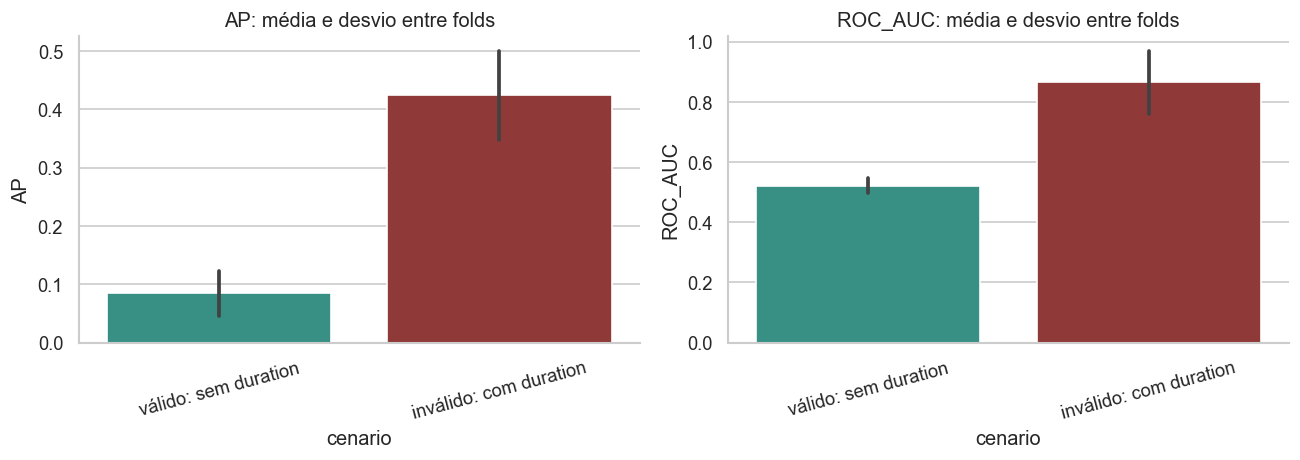


**Resultado:** a AP média sobe de **0.084** para **0.424** quando `duration` entra.
O ganho de **0.340** é estatisticamente atraente e operacionalmente inútil para priorização pré-ligação.

**Decisão:** `duration` permanece banida do pipeline. A lista de colunas excluídas será salva no artefato.


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, metric in zip(axes, ["AP", "ROC_AUC"]):
    sns.barplot(data=leakage_result, x="cenario", y=metric, errorbar="sd", ax=ax, palette=["#2A9D8F", "#9E2A2B"])
    ax.set_title(f"{metric}: média e desvio entre folds")
    ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()

ap_valido = leakage_summary.loc["válido: sem duration", "AP"]
ap_invalido = leakage_summary.loc["inválido: com duration", "AP"]
display(Markdown(f"""
**Resultado:** a AP média sobe de **{ap_valido:.3f}** para **{ap_invalido:.3f}** quando `duration` entra.
O ganho de **{ap_invalido - ap_valido:.3f}** é estatisticamente atraente e operacionalmente inútil para priorização pré-ligação.

**Decisão:** `duration` permanece banida do pipeline. A lista de colunas excluídas será salva no artefato.
"""))

### Pergunta profunda 4

Se `duration` melhora muito o modelo, em qual produto ela poderia ser válida?

<details>
<summary>Resposta guiada</summary>

Ela poderia apoiar uma decisão posterior ao contato, como previsão de conclusão de adesão ou recomendação do próximo passo ao atendente, desde que o alvo e o instante fossem reformulados. Uma mesma coluna pode ser vazamento em um produto e informação legítima em outro.

</details>

## 6. Engenharia de atributos dentro do pipeline

Árvores não exigem padronização porque divisões por ordem são invariantes a escalas monotônicas. A engenharia usada aqui atende quatro necessidades:

1. imputação defensiva de numéricos e categóricos, mesmo que a amostra atual não tenha `NaN`;
2. one-hot encoding com categorias desconhecidas ignoradas;
3. indicador explícito de contato anterior a partir de `pdays > -1`;
4. faixas de idade por quantis, mantidas junto com a idade bruta para demonstrar uma representação operacional estável.

A faixa de idade é redundante para uma árvore, que já aprende cortes. Ela foi incluída por utilidade didática e de relatórios, não por expectativa de ganho automático.

In [12]:
categoricas = X_train.select_dtypes(include="object").columns.tolist()
numericas = X_train.select_dtypes(exclude="object").columns.tolist()

preprocessor = ColumnTransformer([
    ("numericas", SimpleImputer(strategy="median"), numericas),
    ("categoricas", Pipeline([
        ("imputar", SimpleImputer(strategy="most_frequent")),
        ("one_hot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]), categoricas),
    ("contato_anterior", Pipeline([
        ("imputar", SimpleImputer(strategy="constant", fill_value=-1)),
        ("binario", Binarizer(threshold=-0.5)),
    ]), ["pdays"]),
    ("faixa_idade", Pipeline([
        ("imputar", SimpleImputer(strategy="median")),
        ("quantis", KBinsDiscretizer(n_bins=4, encode="onehot-dense", strategy="quantile")),
    ]), ["age"]),
], sparse_threshold=0.0)

# Inspeção ajustada apenas no desenvolvimento. Nas buscas, o objeto será clonado e ajustado por fold.
Z_train_demo = clone(preprocessor).fit_transform(X_train)
print(f"Entradas brutas: {X_train.shape[1]}")
print(f"Atributos após engenharia: {Z_train_demo.shape[1]}")

Entradas brutas: 15
Atributos após engenharia: 54


**Por que o pré-processador está no pipeline:** se o one-hot fosse ajustado antes da validação, ele conheceria categorias dos blocos futuros. Se a imputação fosse calculada no conjunto inteiro, a mediana também carregaria informação do futuro. O pipeline reexecuta o `fit` somente no treino de cada fold.

## 7. Uma árvore rasa para aprender o mecanismo

A primeira árvore terá profundidade 3. Ela serve para interpretar divisões, não para disputar o melhor resultado.

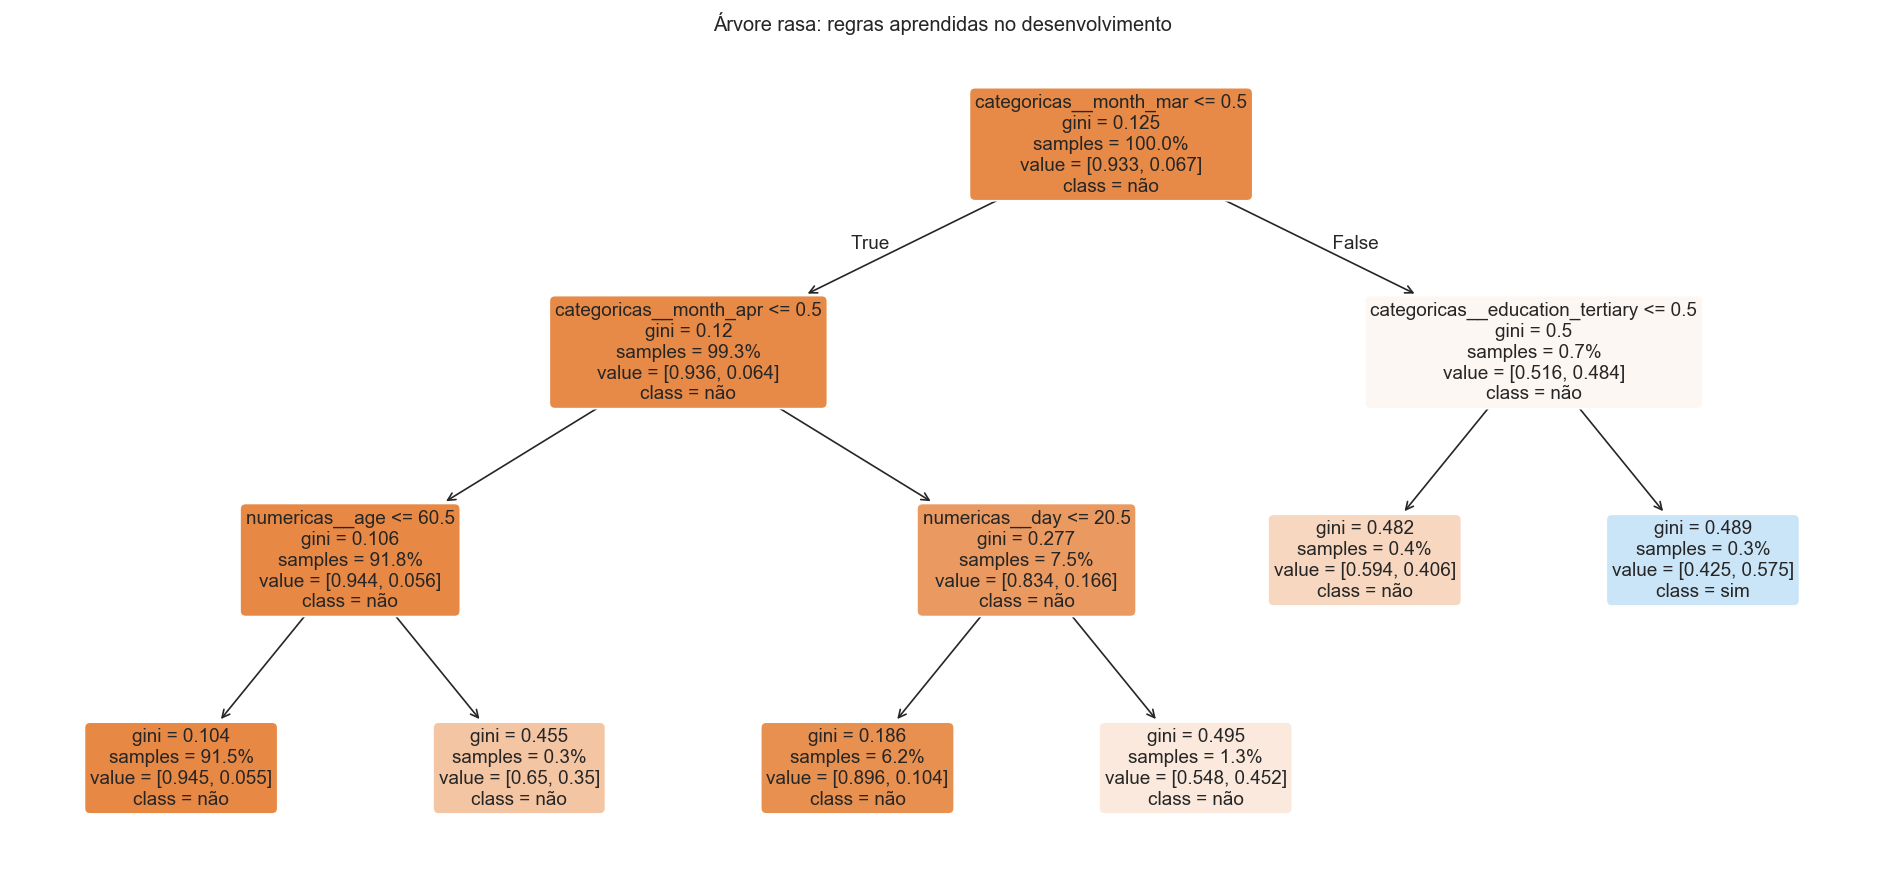

In [13]:
prep_arvore_rasa = clone(preprocessor)
Z_train_rasa = prep_arvore_rasa.fit_transform(X_train)
nomes_rasa = prep_arvore_rasa.get_feature_names_out()

arvore_rasa = DecisionTreeClassifier(
    max_depth=3,
    min_samples_leaf=100,
    random_state=SEED,
)
arvore_rasa.fit(Z_train_rasa, y_train)

fig, ax = plt.subplots(figsize=(20, 9))
plot_tree(
    arvore_rasa,
    feature_names=nomes_rasa,
    class_names=["não", "sim"],
    filled=True,
    rounded=True,
    proportion=True,
    precision=3,
    ax=ax,
)
ax.set_title("Árvore rasa: regras aprendidas no desenvolvimento")
plt.show()

In [14]:
raiz_idx = arvore_rasa.tree_.feature[0]
raiz_nome = nomes_rasa[raiz_idx]
raiz_limiar = arvore_rasa.tree_.threshold[0]
gini_raiz = arvore_rasa.tree_.impurity[0]

display(Markdown(f"""
**Como ler a raiz:** a primeira divisão usa `{raiz_nome}` no limiar **{raiz_limiar:.3f}**.
A impureza de Gini antes da divisão é **{gini_raiz:.3f}**. As amostras que satisfazem a condição seguem para a esquerda.

Essa regra descreve a amostra de desenvolvimento. Ela não estabelece causalidade e pode mudar em outra campanha.
"""))

print(export_text(arvore_rasa, feature_names=list(nomes_rasa), max_depth=3))


**Como ler a raiz:** a primeira divisão usa `categoricas__month_mar` no limiar **0.500**.
A impureza de Gini antes da divisão é **0.125**. As amostras que satisfazem a condição seguem para a esquerda.

Essa regra descreve a amostra de desenvolvimento. Ela não estabelece causalidade e pode mudar em outra campanha.


|--- categoricas__month_mar <= 0.50
|   |--- categoricas__month_apr <= 0.50
|   |   |--- numericas__age <= 60.50
|   |   |   |--- class: 0
|   |   |--- numericas__age >  60.50
|   |   |   |--- class: 0
|   |--- categoricas__month_apr >  0.50
|   |   |--- numericas__day <= 20.50
|   |   |   |--- class: 0
|   |   |--- numericas__day >  20.50
|   |   |   |--- class: 0
|--- categoricas__month_mar >  0.50
|   |--- categoricas__education_tertiary <= 0.50
|   |   |--- class: 0
|   |--- categoricas__education_tertiary >  0.50
|   |   |--- class: 1



### Pergunta profunda 5

Por que uma variável one-hot aparece com limiar próximo de 0,5?

<details>
<summary>Resposta guiada</summary>

Após one-hot encoding, a coluna contém 0 ou 1. Um corte em 0,5 separa ausência e presença da categoria. O número do limiar é simples; a validade da categoria como regra comercial exige análise adicional.

</details>

## 8. Caminho de poda e escolha de `ccp_alpha`

O caminho de poda é extraído no desenvolvimento para construir uma grade pequena. A escolha final usa `TimeSeriesSplit`, preservando a ordem e evitando o teste futuro.

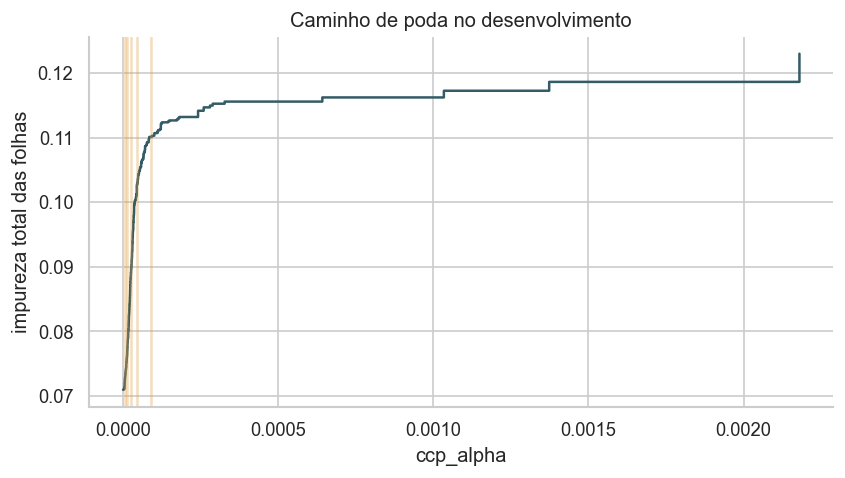

,ccp_alpha candidato
0,0.0000
1,0.0000
2,0.0000
3,0.0000
4,0.0000
5,0.0001


In [15]:
# Uma árvore quase livre produz a sequência de alphas efetivos.
prep_path = clone(preprocessor)
Z_path = prep_path.fit_transform(X_train)
arvore_path = DecisionTreeClassifier(min_samples_leaf=5, random_state=SEED)
path = arvore_path.cost_complexity_pruning_path(Z_path, y_train)

alphas_validos = path.ccp_alphas[:-1]
quantis = np.quantile(alphas_validos, [0.25, 0.50, 0.75, 0.90, 0.97])
alpha_grid = np.unique(np.r_[0.0, quantis])

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(path.ccp_alphas[:-1], path.impurities[:-1], drawstyle="steps-post", color="#335C67")
for alpha in alpha_grid[1:]:
    ax.axvline(alpha, color="#E09F3E", alpha=0.35)
ax.set(xlabel="ccp_alpha", ylabel="impureza total das folhas", title="Caminho de poda no desenvolvimento")
plt.show()

pd.Series(alpha_grid, name="ccp_alpha candidato").to_frame()

In [16]:
cv_temporal = TimeSeriesSplit(n_splits=3)

pipeline_cart = Pipeline([
    ("features", clone(preprocessor)),
    ("modelo", DecisionTreeClassifier(min_samples_leaf=5, random_state=SEED)),
])

busca_poda = GridSearchCV(
    estimator=pipeline_cart,
    param_grid={"modelo__ccp_alpha": alpha_grid},
    scoring="average_precision",
    cv=cv_temporal,
    return_train_score=True,
    n_jobs=1,
)
busca_poda.fit(X_train, y_train)

poda_result = pd.DataFrame(busca_poda.cv_results_)[[
    "param_modelo__ccp_alpha", "mean_train_score", "mean_test_score", "std_test_score", "rank_test_score"
]].rename(columns={
    "param_modelo__ccp_alpha": "ccp_alpha",
    "mean_train_score": "AP_treino",
    "mean_test_score": "AP_validacao",
    "std_test_score": "AP_desvio",
    "rank_test_score": "ranking",
}).sort_values("ccp_alpha")

poda_result

,ccp_alpha,AP_treino,AP_validacao,AP_desvio,ranking
0,0.0000,0.4693,0.0797,0.0286,6
1,0.0000,0.4691,0.0800,0.0290,5
2,0.0000,0.4539,0.0801,0.0284,4
3,0.0000,0.4027,0.0816,0.0273,3
4,0.0000,0.2777,0.0824,0.0356,2
5,0.0001,0.1290,0.0827,0.0318,1


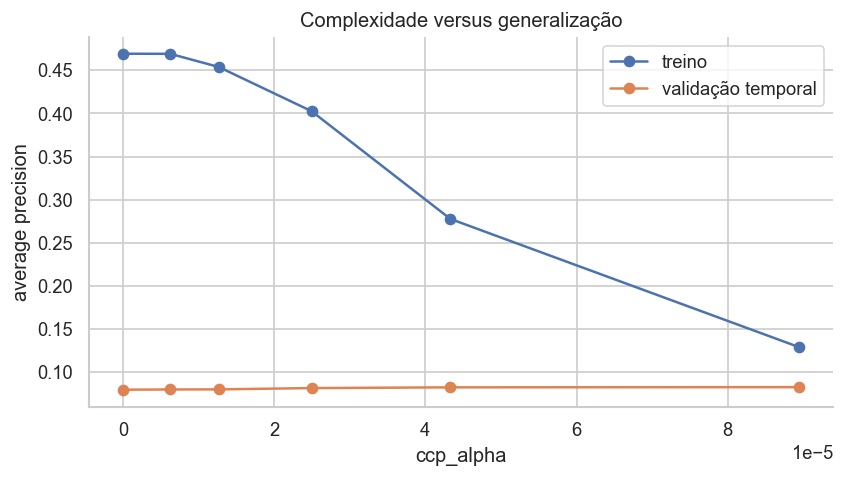


**Decisão:** `ccp_alpha = 0.0000895` obteve a melhor AP média de validação (**0.083**).
A distância entre treino e validação mostra por que a árvore não deve ser escolhida pelo ajuste aparente.


In [17]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(poda_result["ccp_alpha"], poda_result["AP_treino"], marker="o", label="treino")
ax.plot(poda_result["ccp_alpha"], poda_result["AP_validacao"], marker="o", label="validação temporal")
ax.set(xlabel="ccp_alpha", ylabel="average precision", title="Complexidade versus generalização")
ax.legend()
plt.show()

best_alpha = float(busca_poda.best_params_["modelo__ccp_alpha"])
best_row = poda_result.loc[poda_result["ranking"].eq(1)].iloc[0]
display(Markdown(f"""
**Decisão:** `ccp_alpha = {best_alpha:.7f}` obteve a melhor AP média de validação (**{best_row.AP_validacao:.3f}**).
A distância entre treino e validação mostra por que a árvore não deve ser escolhida pelo ajuste aparente.
"""))

## 9. Candidatos e protocolo de comparação

Serão comparados:

- baseline pela prevalência;
- CART sem poda, como diagnóstico de alta variância;
- CART podada com `ccp_alpha` validado;
- bagging de árvores;
- random forest;
- histogram gradient boosting.

O benchmark usa os mesmos três folds temporais e AP como critério primário. Tempo, log loss, AUC e distância treino-validação entram na decisão crítica.

In [18]:
candidatos = {
    "Dummy prevalência": DummyClassifier(strategy="prior"),
    "CART livre": DecisionTreeClassifier(random_state=SEED),
    "CART podada": DecisionTreeClassifier(
        min_samples_leaf=5,
        ccp_alpha=best_alpha,
        random_state=SEED,
    ),
    "Bagging": BaggingClassifier(
        estimator=DecisionTreeClassifier(min_samples_leaf=25, random_state=SEED),
        n_estimators=80,
        max_samples=0.80,
        oob_score=True,
        n_jobs=1,
        random_state=SEED,
    ),
    "Random forest": RandomForestClassifier(
        n_estimators=150,
        min_samples_leaf=10,
        max_features="sqrt",
        oob_score=True,
        n_jobs=1,
        random_state=SEED,
    ),
    "HistGradientBoosting": HistGradientBoostingClassifier(
        max_iter=150,
        learning_rate=0.06,
        max_leaf_nodes=31,
        min_samples_leaf=30,
        l2_regularization=1.0,
        random_state=SEED,
    ),
}

pipelines = {
    nome: Pipeline([("features", clone(preprocessor)), ("modelo", estimador)])
    for nome, estimador in candidatos.items()
}

In [19]:
linhas_cv = []
for nome, pipeline in pipelines.items():
    inicio = time.perf_counter()
    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv_temporal,
        scoring={
            "AP": "average_precision",
            "ROC_AUC": "roc_auc",
            "neg_log_loss": "neg_log_loss",
        },
        return_train_score=True,
        n_jobs=1,
    )
    linhas_cv.append({
        "modelo": nome,
        "AP_media": scores["test_AP"].mean(),
        "AP_desvio": scores["test_AP"].std(ddof=1),
        "AP_treino": scores["train_AP"].mean(),
        "ROC_AUC": scores["test_ROC_AUC"].mean(),
        "log_loss": -scores["test_neg_log_loss"].mean(),
        "tempo_s": time.perf_counter() - inicio,
    })

cv_table = pd.DataFrame(linhas_cv).sort_values("AP_media", ascending=False).reset_index(drop=True)
cv_table["gap_AP"] = cv_table["AP_treino"] - cv_table["AP_media"]
cv_table

,modelo,AP_media,AP_desvio,AP_treino,ROC_AUC,log_loss,tempo_s,gap_AP
0,Random forest,0.0945,0.0490,0.5403,0.5409,0.2788,7.1512,0.4458
1,Bagging,0.0914,0.0419,0.3530,0.5389,0.2820,14.4891,0.2616
2,HistGradientBoosting,0.0908,0.0491,0.4154,0.5371,0.2928,1.9532,0.3245
3,CART podada,0.0827,0.0389,0.1290,0.5065,0.3019,0.6751,0.0463
4,CART livre,0.0790,0.0346,1.0000,0.5030,5.0320,0.7054,0.9210
5,Dummy prevalência,0.0785,0.0342,0.0430,0.5000,0.2848,0.3806,-0.0355


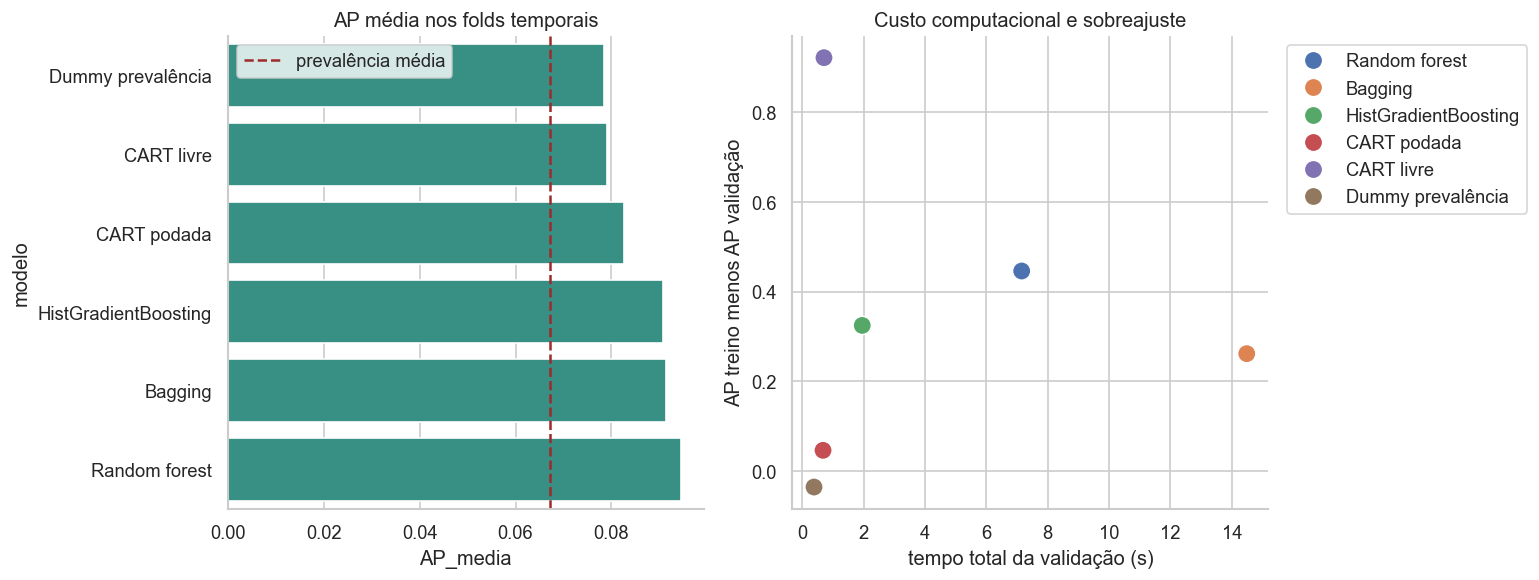

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ordem = cv_table.sort_values("AP_media")["modelo"]
sns.barplot(data=cv_table, y="modelo", x="AP_media", order=ordem, color="#2A9D8F", ax=axes[0])
axes[0].axvline(y_train.mean(), color="#9E2A2B", linestyle="--", label="prevalência média")
axes[0].set_title("AP média nos folds temporais")
axes[0].legend()

sns.scatterplot(data=cv_table, x="tempo_s", y="gap_AP", hue="modelo", s=120, ax=axes[1])
axes[1].set_title("Custo computacional e sobreajuste")
axes[1].set_xlabel("tempo total da validação (s)")
axes[1].set_ylabel("AP treino menos AP validação")
axes[1].legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [21]:
# Regra pré-definida: maior AP média de validação. O teste ainda não foi consultado.
selected_name = cv_table.iloc[0]["modelo"]
selected_pipeline = pipelines[selected_name]

linha_sel = cv_table.iloc[0]
display(Markdown(f"""
### Modelo congelado: {selected_name}

- AP média temporal: **{linha_sel.AP_media:.3f}**;
- ROC AUC média: **{linha_sel.ROC_AUC:.3f}**;
- log loss média: **{linha_sel.log_loss:.3f}**;
- gap de AP entre treino e validação: **{linha_sel.gap_AP:.3f}**.

A seleção obedece ao protocolo, mesmo que outro candidato pareça melhor quando o teste for aberto.
"""))


### Modelo congelado: Random forest

- AP média temporal: **0.095**;
- ROC AUC média: **0.541**;
- log loss média: **0.279**;
- gap de AP entre treino e validação: **0.446**.

A seleção obedece ao protocolo, mesmo que outro candidato pareça melhor quando o teste for aberto.


### Pergunta profunda 6

Por que um modelo com AP de treino alta e AP temporal baixa pode ser pior que um modelo menos ajustado?

<details>
<summary>Resposta guiada</summary>

O objetivo é generalizar para dados posteriores. A diferença grande sugere que o modelo capturou particularidades do passado. Árvores livres são especialmente suscetíveis porque podem isolar poucas observações em folhas quase puras.

</details>

## 10. Out-of-bag: útil, mas não suficiente

No bagging e no random forest, cada árvore deixa parte das linhas fora de sua amostra bootstrap. Essas linhas podem estimar erro sem um conjunto separado.

O OOB mistura períodos do desenvolvimento e usa acurácia por padrão. Ele não substitui a validação temporal nem a AP em uma classe rara.

In [22]:
# Ajustamos os dois ensembles no desenvolvimento para inspecionar o OOB.
oob_rows = []
for nome in ["Bagging", "Random forest"]:
    pipe = clone(pipelines[nome]).fit(X_train, y_train)
    oob_rows.append({
        "modelo": nome,
        "OOB_acuracia": pipe.named_steps["modelo"].oob_score_,
    })

oob_table = pd.DataFrame(oob_rows)
oob_table["baseline_maior_classe"] = max(y_train.mean(), 1 - y_train.mean())
oob_table["ganho_sobre_baseline"] = oob_table["OOB_acuracia"] - oob_table["baseline_maior_classe"]
oob_table

,modelo,OOB_acuracia,baseline_maior_classe,ganho_sobre_baseline
0,Bagging,0.9331,0.9327,0.0003
1,Random forest,0.9328,0.9327,0.0001


**Interpretação:** valores OOB altos podem impressionar, mas o baseline “todos não aderem” já tem acurácia elevada no desenvolvimento. A comparação correta precisa considerar o ganho sobre esse baseline e a capacidade de ordenar positivos.

## 11. Reajuste final e abertura única do teste futuro

Agora o pipeline selecionado é ajustado em todo o desenvolvimento. O teste final participa apenas desta avaliação e das análises posteriores. Ele não volta para o processo de seleção.

In [24]:
inicio_fit = time.perf_counter()
final_pipeline = clone(selected_pipeline).fit(X_train, y_train)
fit_seconds = time.perf_counter() - inicio_fit

inicio_pred = time.perf_counter()
p_test = final_pipeline.predict_proba(X_test)[:, 1]
predict_ms_1000 = (time.perf_counter() - inicio_pred) * 1000 / len(X_test) * 1000

dummy_final = Pipeline([
    ("features", clone(preprocessor)),
    ("modelo", DummyClassifier(strategy="prior")),
]).fit(X_train, y_train)
p_dummy = dummy_final.predict_proba(X_test)[:, 1]

test_metrics = pd.DataFrame({
    "modelo": [selected_name, "Dummy prevalência do treino"],
    "AP": [average_precision_score(y_test, p_test), average_precision_score(y_test, p_dummy)],
    "ROC_AUC": [roc_auc_score(y_test, p_test), roc_auc_score(y_test, p_dummy)],
    "log_loss": [log_loss(y_test, p_test), log_loss(y_test, p_dummy)],
    "Brier": [brier_score_loss(y_test, p_test), brier_score_loss(y_test, p_dummy)],
    "prob_media": [p_test.mean(), p_dummy.mean()],
})

print(f"Tempo de ajuste final: {fit_seconds:.2f} s")
print(f"Latência aproximada: {predict_ms_1000:.2f} ms por 1.000 linhas")
test_metrics

Tempo de ajuste final: 4.73 s
Latência aproximada: 14.00 ms por 1.000 linhas


,modelo,AP,ROC_AUC,log_loss,Brier,prob_media
0,Random forest,0.4665,0.6957,0.6864,0.2289,0.1442
1,Dummy prevalência do treino,0.3158,0.5000,0.9001,0.2779,0.0673


In [27]:
ap_test = test_metrics.loc[0, "AP"]
auc_test = test_metrics.loc[0, "ROC_AUC"]
display(Markdown(f"""
**Leitura do teste futuro:** o modelo alcança AP **{ap_test:.3f}** contra prevalência **{y_test.mean():.3f}**,
e ROC AUC **{auc_test:.3f}**. Há capacidade de ranqueamento, mas a probabilidade média prevista
(**{p_test.mean():.1%}**) fica distante da taxa observada (**{y_test.mean():.1%}**).

Essa distância é evidência de mudança de base e calibração fraca. Para uma fila por ranking, o modelo ainda pode ser útil.
Para cálculo de valor esperado por probabilidade, ele precisa de recalibração temporal com dados posteriores ao desenvolvimento.
"""))


**Leitura do teste futuro:** o modelo alcança AP **0.466** contra prevalência **0.316**,
e ROC AUC **0.696**. Há capacidade de ranqueamento, mas a probabilidade média prevista
(**14.4%**) fica distante da taxa observada (**31.6%**).

Essa distância é evidência de mudança de base e calibração fraca. Para uma fila por ranking, o modelo ainda pode ser útil.
Para cálculo de valor esperado por probabilidade, ele precisa de recalibração temporal com dados posteriores ao desenvolvimento.


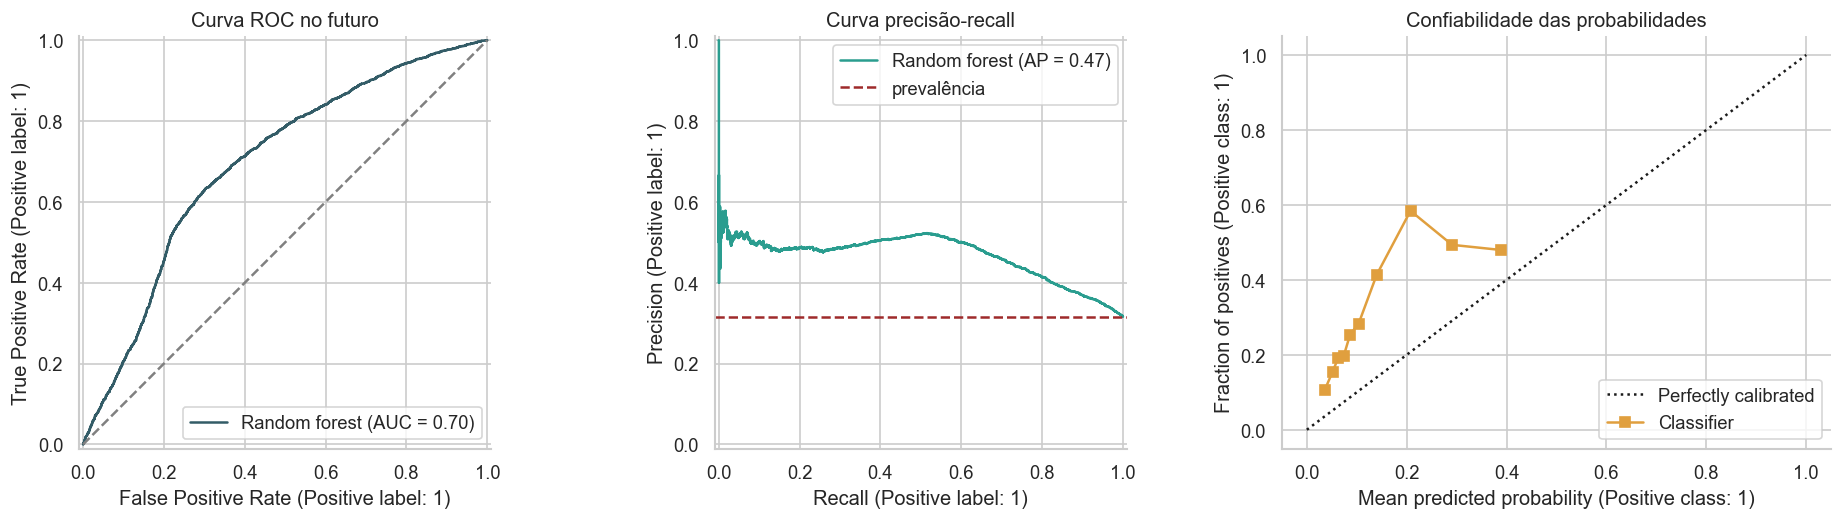

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
RocCurveDisplay.from_predictions(y_test, p_test, name=selected_name, ax=axes[0], color="#335C67")
axes[0].plot([0, 1], [0, 1], "--", color="gray")
axes[0].set_title("Curva ROC no futuro")

PrecisionRecallDisplay.from_predictions(y_test, p_test, name=selected_name, ax=axes[1], color="#2A9D8F")
axes[1].axhline(y_test.mean(), linestyle="--", color="#9E2A2B", label="prevalência")
axes[1].set_title("Curva precisão-recall")
axes[1].legend()

CalibrationDisplay.from_predictions(y_test, p_test, n_bins=10, strategy="quantile", ax=axes[2], color="#E09F3E")
axes[2].set_title("Confiabilidade das probabilidades")
plt.tight_layout()
plt.show()

### Pergunta profunda 7

Um modelo pode ter AUC razoável e calibração ruim ao mesmo tempo?

<details>
<summary>Resposta guiada</summary>

Sim. AUC depende da ordem dos escores: positivos devem receber valores maiores que negativos. Calibração exige que grupos previstos com 20% de probabilidade apresentem perto de 20% de eventos. Uma mudança de prevalência pode preservar parte da ordem e deslocar as probabilidades.

</details>

## 12. Da previsão à política de capacidade

A equipe pode ligar para 20% da carteira. A política é definida por ranking, então o limiar numérico varia com a distribuição dos escores.

Serão calculados:

- **precisão@20%:** proporção de adesões entre os contatados;
- **recall@20%:** proporção de todas as adesões capturada pela fila;
- **lift@20%:** precisão da fila dividida pela taxa geral;
- **lucro retrospectivo:** adesões observadas vezes €200, menos contatos vezes €10.

In [29]:
def metricas_capacidade(y_true, scores, capacidade):
    '''Avalia uma política que seleciona a fração superior do ranking.'''
    y_arr = np.asarray(y_true)
    n_select = max(1, int(np.floor(len(y_arr) * capacidade)))
    ordem = np.argsort(scores)[::-1]
    selecionados = ordem[:n_select]
    decisao = np.zeros(len(y_arr), dtype=int)
    decisao[selecionados] = 1
    positivos = y_arr[selecionados].sum()
    precisao = positivos / n_select
    recall = positivos / y_arr.sum()
    lucro = positivos * VALOR_ADESAO - n_select * CUSTO_CONTATO
    return {
        "capacidade": capacidade,
        "contatos": n_select,
        "adesoes": int(positivos),
        "precisao": precisao,
        "recall": recall,
        "lift": precisao / y_arr.mean(),
        "limiar_score": float(scores[selecionados].min()),
        "lucro_retrospectivo_eur": lucro,
    }, decisao


cap_rows = []
for cap in [0.05, 0.10, 0.20, 0.30, 0.50, 1.00]:
    row, _ = metricas_capacidade(y_test, p_test, cap)
    cap_rows.append(row)
capacity_table = pd.DataFrame(cap_rows)

policy_20, decisao_20 = metricas_capacidade(y_test, p_test, CAPACIDADE)
capacity_table

,capacidade,contatos,adesoes,precisao,recall,lift,limiar_score,lucro_retrospectivo_eur
0,0.0500,452,226,0.5000,0.0791,1.5832,0.3788,"40,680.0000"
1,0.1000,904,433,0.4790,0.1516,1.5166,0.3321,"77,560.0000"
2,0.2000,1808,880,0.4867,0.3081,1.5411,0.2470,"157,920.0000"
3,0.3000,2712,1408,0.5192,0.4930,1.6439,0.1738,"254,480.0000"
4,0.5000,4521,2038,0.4508,0.7136,1.4273,0.0944,"362,390.0000"
5,1.0000,9043,2856,0.3158,1.0000,1.0000,0.0134,"480,770.0000"


In [30]:
lucro_aleatorio = policy_20["contatos"] * (y_test.mean() * VALOR_ADESAO - CUSTO_CONTATO)
ganho_lucro = policy_20["lucro_retrospectivo_eur"] - lucro_aleatorio

display(Markdown(f"""
### Política recomendada para o experimento

Ao contatar **{policy_20['contatos']:,} clientes** (20% do teste), a fila contém
**{policy_20['adesoes']:,} adesões**, precisão de **{policy_20['precisao']:.1%}**,
recall de **{policy_20['recall']:.1%}** e lift de **{policy_20['lift']:.2f}×**.

Sob os valores hipotéticos, o lucro retrospectivo é **€{policy_20['lucro_retrospectivo_eur']:,.0f}**,
contra **€{lucro_aleatorio:,.0f}** para seleção aleatória de igual tamanho. O ganho estimado é
**€{ganho_lucro:,.0f}**.

O cálculo é uma análise de cenário. Ele usa desfechos observados, não identifica efeito causal da ligação e não inclui
capacidade por atendente, recusas, custos regulatórios ou canibalização.
"""))


### Política recomendada para o experimento

Ao contatar **1,808 clientes** (20% do teste), a fila contém
**880 adesões**, precisão de **48.7%**,
recall de **30.8%** e lift de **1.54×**.

Sob os valores hipotéticos, o lucro retrospectivo é **€157,920**,
contra **€96,122** para seleção aleatória de igual tamanho. O ganho estimado é
**€61,798**.

O cálculo é uma análise de cenário. Ele usa desfechos observados, não identifica efeito causal da ligação e não inclui
capacidade por atendente, recusas, custos regulatórios ou canibalização.


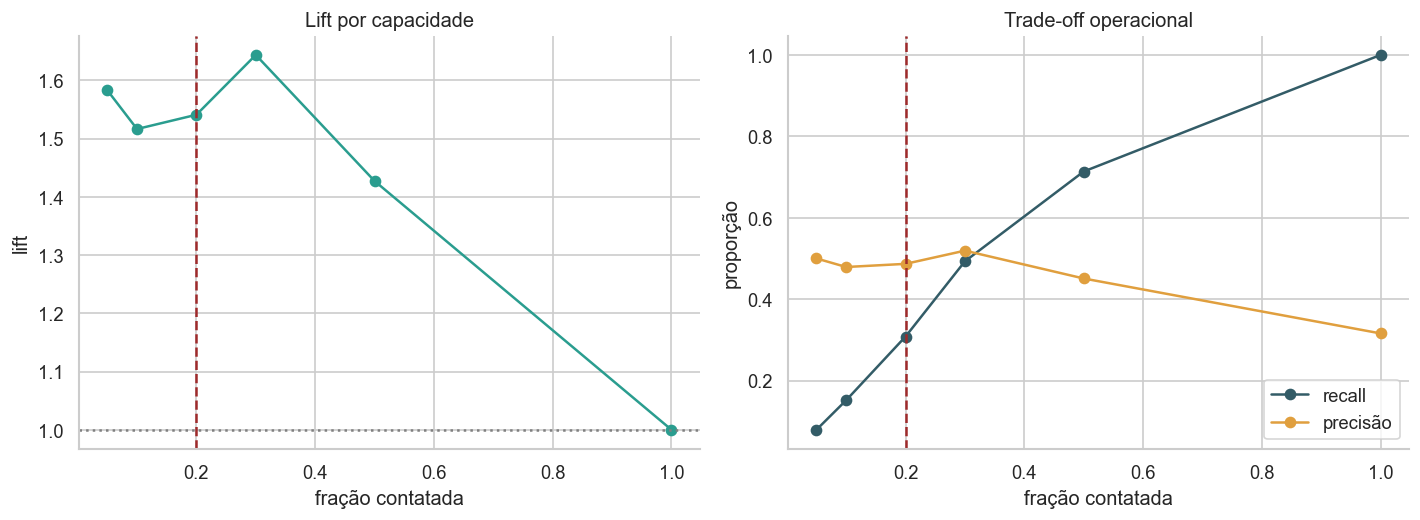

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(capacity_table["capacidade"], capacity_table["lift"], marker="o", color="#2A9D8F")
axes[0].axvline(CAPACIDADE, linestyle="--", color="#9E2A2B")
axes[0].axhline(1, linestyle=":", color="gray")
axes[0].set(title="Lift por capacidade", xlabel="fração contatada", ylabel="lift")

axes[1].plot(capacity_table["capacidade"], capacity_table["recall"], marker="o", color="#335C67", label="recall")
axes[1].plot(capacity_table["capacidade"], capacity_table["precisao"], marker="o", color="#E09F3E", label="precisão")
axes[1].axvline(CAPACIDADE, linestyle="--", color="#9E2A2B")
axes[1].set(title="Trade-off operacional", xlabel="fração contatada", ylabel="proporção")
axes[1].legend()
plt.tight_layout()
plt.show()

### Pergunta profunda 8

Por que o limiar 0,5 não foi usado para definir a fila?

<details>
<summary>Resposta guiada</summary>

O negócio tem uma restrição de capacidade, e as probabilidades estão descalibradas no período futuro. Um quantil de ranking atende diretamente à capacidade. Um limiar econômico por probabilidade só seria defensável após estimar valores reais, efeito incremental da ação e calibração temporal.

</details>

## 13. Interpretação: impureza, permutação e dependência parcial

Importância por impureza mede quanto uma variável foi usada para reduzir impureza nas árvores. Ela pode favorecer atributos contínuos ou de alta cardinalidade e usa o próprio treino.

Importância por permutação mede quanto a AP cai ao embaralhar uma entrada no teste. Ela é agnóstica ao modelo, mas pode dividir importância entre atributos correlacionados.

Nenhuma das duas prova causalidade.

In [32]:
modelo_final = final_pipeline.named_steps["modelo"]
prep_final = final_pipeline.named_steps["features"]

if hasattr(modelo_final, "feature_importances_"):
    mdi = pd.DataFrame({
        "atributo_transformado": prep_final.get_feature_names_out(),
        "importancia_MDI": modelo_final.feature_importances_,
    }).sort_values("importancia_MDI", ascending=False).head(12)
else:
    mdi = pd.DataFrame(columns=["atributo_transformado", "importancia_MDI"])
    print("O estimador selecionado não expõe feature_importances_.")

# Amostra fixa reduz o custo sem usar o resultado para seleção.
idx_perm = X_test.sample(n=min(3000, len(X_test)), random_state=SEED).index
perm = permutation_importance(
    final_pipeline,
    X_test.loc[idx_perm],
    y_test.loc[idx_perm],
    scoring="average_precision",
    n_repeats=3,
    random_state=SEED,
    n_jobs=1,
)
permutacao = pd.DataFrame({
    "atributo_bruto": X_test.columns,
    "queda_AP_media": perm.importances_mean,
    "queda_AP_desvio": perm.importances_std,
}).sort_values("queda_AP_media", ascending=False)

display(mdi)
display(permutacao.head(12))

,atributo_transformado,importancia_MDI
2,numericas__day,0.1315
1,numericas__balance,0.1262
0,numericas__age,0.1198
41,categoricas__month_mar,0.0807
34,categoricas__month_apr,0.0710
3,numericas__campaign,0.0481
44,categoricas__month_oct,0.0373
27,categoricas__housing_no,0.0294
28,categoricas__housing_yes,0.0266
47,categoricas__poutcome_success,0.0216


,atributo_bruto,queda_AP_media,queda_AP_desvio
14,poutcome,0.0621,0.0018
10,month,0.0541,0.0067
0,age,0.0161,0.0038
6,housing,0.0149,0.0003
9,day,0.0112,0.0026
5,balance,0.0054,0.0008
3,education,0.0040,0.0006
12,pdays,0.0017,0.0007
11,campaign,0.0003,0.0003
4,default,-0.0000,0.0000


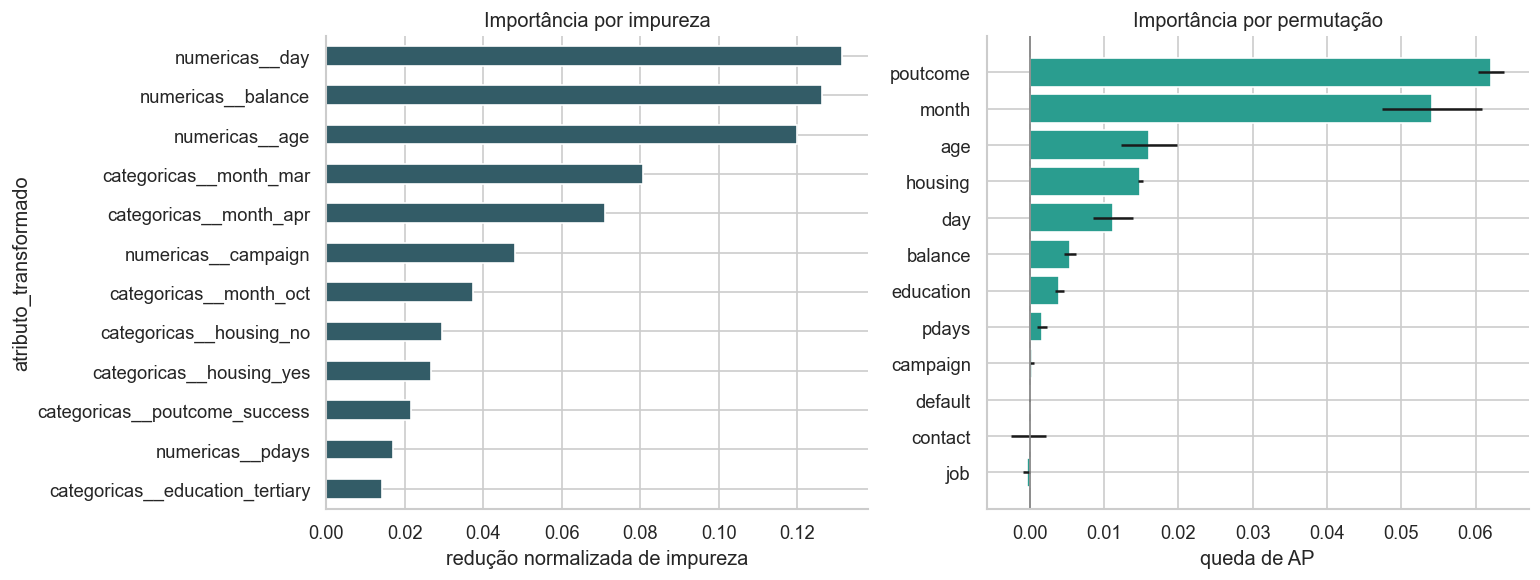

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

if len(mdi):
    mdi.sort_values("importancia_MDI").plot.barh(
        x="atributo_transformado", y="importancia_MDI", legend=False, ax=axes[0], color="#335C67"
    )
axes[0].set_title("Importância por impureza")
axes[0].set_xlabel("redução normalizada de impureza")

top_perm = permutacao.head(12).sort_values("queda_AP_media")
axes[1].barh(top_perm["atributo_bruto"], top_perm["queda_AP_media"], xerr=top_perm["queda_AP_desvio"], color="#2A9D8F")
axes[1].axvline(0, color="gray", linewidth=1)
axes[1].set_title("Importância por permutação")
axes[1].set_xlabel("queda de AP")

plt.tight_layout()
plt.show()

**Como avaliar diferenças entre os gráficos:** MDI pode distribuir importância entre várias dummies da mesma variável e favorecer muitas oportunidades de corte. A permutação trabalha na coluna bruta antes do pipeline. Se uma variável for substituível por outra correlacionada, embaralhar apenas uma pode produzir queda pequena.

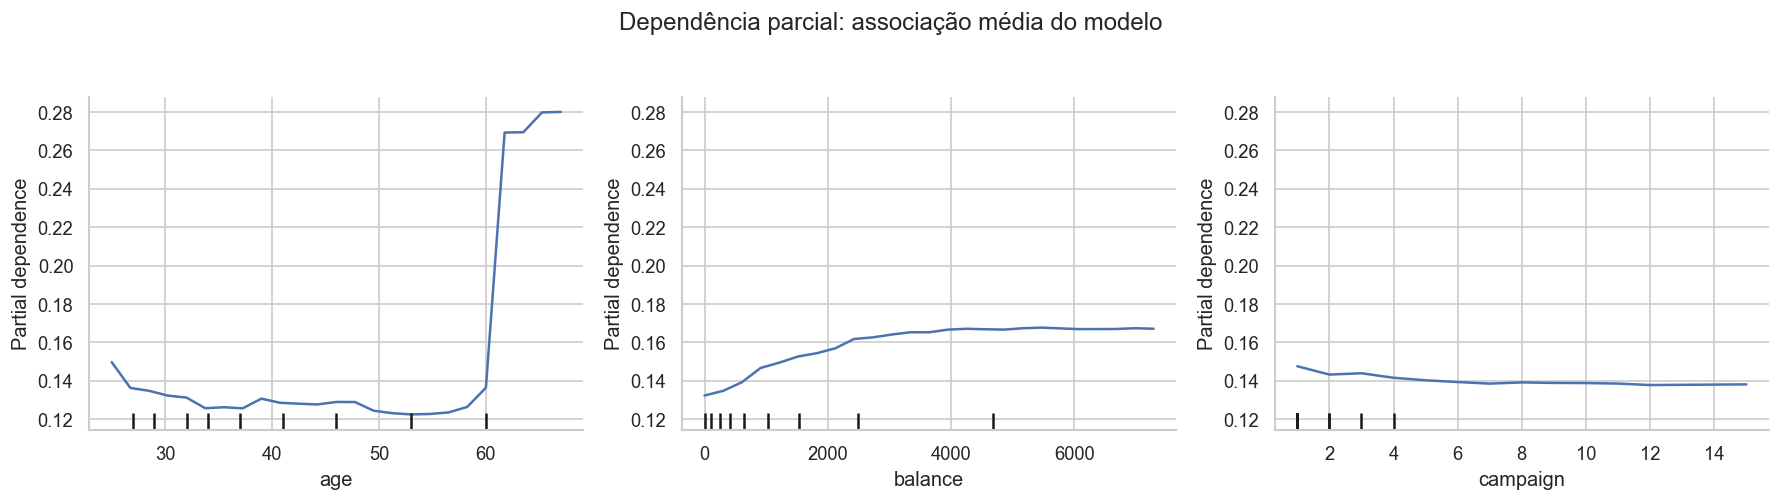

In [35]:
# PDP descreve a média das previsões ao variar uma entrada e manter as demais como observadas.
amostra_pdp = X_test.sample(n=min(1500, len(X_test)), random_state=SEED)
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
PartialDependenceDisplay.from_estimator(
    final_pipeline,
    amostra_pdp,
    features=["age", "balance", "campaign"],
    grid_resolution=25,
    kind="average",
    ax=ax,
)
fig.suptitle("Dependência parcial: associação média do modelo", y=1.04)
plt.tight_layout()
plt.show()

**Limite da dependência parcial:** o gráfico cria combinações sintéticas. Se idade, ocupação, saldo e empréstimos forem dependentes, alguns pontos avaliados podem ser raros ou impossíveis. A curva explica o comportamento do modelo, não o efeito de alterar uma característica da pessoa.

## 14. Análise de erros e grupos operacionais

A decisão final é a fila de 20%. Vamos comparar volume, taxa observada e seleção por ocupação e faixa etária. A finalidade é encontrar segmentos com desempenho diferente e levantar hipóteses de processo.

In [36]:
avaliacao = X_test[["job", "age", "contact", "month"]].copy()
avaliacao["y"] = y_test.to_numpy()
avaliacao["score"] = p_test
avaliacao["selecionado"] = decisao_20
avaliacao["faixa_idade"] = pd.cut(
    avaliacao["age"], bins=[0, 29, 44, 59, np.inf], labels=["até 29", "30-44", "45-59", "60+"]
)

def resumo_grupo(frame, coluna):
    def precision_selected(g):
        mask = g["selecionado"].eq(1)
        return g.loc[mask, "y"].mean() if mask.any() else np.nan
    return (
        frame.groupby(coluna, observed=True)
        .apply(lambda g: pd.Series({
            "linhas": len(g),
            "taxa_adesao": g["y"].mean(),
            "taxa_selecao": g["selecionado"].mean(),
            "precisao_selecionados": precision_selected(g),
            "score_medio": g["score"].mean(),
        }), include_groups=False)
        .sort_values("linhas", ascending=False)
    )

job_audit = resumo_grupo(avaliacao, "job")
age_audit = resumo_grupo(avaliacao, "faixa_idade")
display(job_audit)
display(age_audit)

,linhas,taxa_adesao,taxa_selecao,precisao_selecionados,score_medio
job,,,,,
management,"1,901.0000",0.3751,0.1857,0.5382,0.1489
blue-collar,"1,566.0000",0.1775,0.0524,0.4756,0.0839
technician,"1,249.0000",0.3275,0.1409,0.5455,0.1326
admin.,"1,204.0000",0.2957,0.1404,0.4379,0.1294
retired,897.0000,0.4192,0.7737,0.4395,0.2926
services,710.0000,0.2648,0.0535,0.6316,0.0935
student,522.0000,0.3985,0.1686,0.6023,0.1732
self-employed,274.0000,0.3212,0.1715,0.6170,0.1467
unemployed,261.0000,0.4406,0.2107,0.5455,0.1599


,linhas,taxa_adesao,taxa_selecao,precisao_selecionados,score_medio
faixa_idade,,,,,
30-44,"4,272.0000",0.2715,0.1025,0.5160,0.1124
45-59,"1,964.0000",0.3269,0.1293,0.5079,0.1210
até 29,"1,713.0000",0.3374,0.1366,0.5598,0.1487
60+,"1,094.0000",0.4351,0.8062,0.4467,0.3031


**Leitura responsável:** diferenças de seleção são sinais para investigação, não evidência de tratamento justo ou injusto. A base não documenta consentimento, proteção legal, identidade de clientes nem todas as variáveis de contexto. Antes de produção seriam necessários critérios jurídicos, avaliação de impacto, revisão humana e métricas de qualidade por grupos relevantes.

## 15. Drift e monitoramento

O teste já mostrou mudança no alvo. Agora mediremos mudança de distribuição em atributos numéricos pelo Population Stability Index (PSI):

$$PSI=\sum_b (q_b-p_b)\log\left(\frac{q_b}{p_b}\right).$$

Os cortes vêm do desenvolvimento. Valores próximos de zero indicam distribuições semelhantes. Limiares como 0,1 e 0,25 são heurísticas, não leis universais.

In [37]:
def psi_numeric(reference, current, bins=10):
    '''PSI com quantis da referência e proteção numérica.'''
    ref = pd.Series(reference).dropna().astype(float)
    cur = pd.Series(current).dropna().astype(float)
    edges = np.unique(np.quantile(ref, np.linspace(0, 1, bins + 1)))
    edges[0], edges[-1] = -np.inf, np.inf
    ref_p = pd.cut(ref, edges, include_lowest=True).value_counts(normalize=True, sort=False)
    cur_p = pd.cut(cur, edges, include_lowest=True).value_counts(normalize=True, sort=False)
    eps = 1e-6
    return float(((cur_p.clip(eps) - ref_p.clip(eps)) * np.log(cur_p.clip(eps) / ref_p.clip(eps))).sum())


psi_table = pd.DataFrame({
    "atributo": numericas,
    "PSI": [psi_numeric(X_train[c], X_test[c]) for c in numericas],
}).sort_values("PSI", ascending=False)

novas_categorias = []
for c in categoricas:
    desconhecidas = sorted(set(X_test[c].dropna()) - set(X_train[c].dropna()))
    novas_categorias.append({"atributo": c, "categorias_novas": ", ".join(map(str, desconhecidas)), "quantidade": len(desconhecidas)})
novas_categorias = pd.DataFrame(novas_categorias).sort_values("quantidade", ascending=False)

display(psi_table)
display(novas_categorias)

,atributo,PSI
4,pdays,0.7354
2,day,0.5739
5,previous,0.5278
0,age,0.1572
3,campaign,0.0834
1,balance,0.0682


,atributo,categorias_novas,quantidade
7,month,sep,1
0,job,,0
1,marital,,0
3,default,,0
2,education,,0
4,housing,,0
5,loan,,0
6,contact,,0
8,poutcome,,0


In [38]:
maior_psi = psi_table.iloc[0]
novas_total = novas_categorias["quantidade"].sum()
display(Markdown(f"""
**Diagnóstico:** o maior PSI numérico aparece em `{maior_psi.atributo}` com **{maior_psi.PSI:.3f}**.
O teste contém **{novas_total}** categorias não vistas no desenvolvimento. O `OneHotEncoder(handle_unknown='ignore')`
impede falha técnica, mas não resolve o desconhecimento do modelo sobre o novo regime.

Um painel de produção deveria acompanhar distribuição de entradas, taxa de categorias novas, distribuição do escore,
taxa de adesão quando o rótulo chegar, AP por coorte, calibração e lift na capacidade operacional.
"""))


**Diagnóstico:** o maior PSI numérico aparece em `pdays` com **0.735**.
O teste contém **1** categorias não vistas no desenvolvimento. O `OneHotEncoder(handle_unknown='ignore')`
impede falha técnica, mas não resolve o desconhecimento do modelo sobre o novo regime.

Um painel de produção deveria acompanhar distribuição de entradas, taxa de categorias novas, distribuição do escore,
taxa de adesão quando o rótulo chegar, AP por coorte, calibração e lift na capacidade operacional.


### Pergunta profunda 9

Por que “o pipeline aceitou a nova categoria” não significa “o modelo sabe tratá-la”?

<details>
<summary>Resposta guiada</summary>

Com `handle_unknown='ignore'`, todas as dummies daquela variável ficam zeradas para a categoria nova. O código continua, mas o modelo nunca aprendeu seu comportamento. A robustez de software evita uma exceção; a validade estatística ainda precisa ser verificada.

</details>

## 16. Persistência do pipeline e contrato de inferência

O artefato salvará o pipeline completo, a ordem das colunas, a lista de variáveis banidas, a política e as versões. Assim, o one-hot, as faixas, a imputação e o modelo viajam juntos.

Usaremos `joblib`, que emprega serialização compatível com pickle e é adequada para objetos NumPy grandes. Pickles nunca devem ser carregados de origem não confiável, pois a desserialização pode executar código.

In [34]:
ARTEFATOS = Path("artifacts")
ARTEFATOS.mkdir(exist_ok=True)
MODEL_PATH = ARTEFATOS / "pipeline_bank_marketing_arvores.pkl"

bundle = {
    "pipeline": final_pipeline,
    "feature_columns": X_train.columns.tolist(),
    "target": "y",
    "excluded_columns": ["duration"],
    "decision_moment": "antes da ligação da campanha atual",
    "policy": {
        "capacity": CAPACIDADE,
        "value_subscription_eur_demo": VALOR_ADESAO,
        "contact_cost_eur_demo": CUSTO_CONTATO,
    },
    "selected_model": selected_name,
    "test_metrics": test_metrics.set_index("modelo").to_dict(orient="index"),
    "versions": versoes.to_dict(),
}

joblib.dump(bundle, MODEL_PATH, compress=3)
print(f"Artefato salvo: {MODEL_PATH.resolve()}")
print(f"Tamanho: {MODEL_PATH.stat().st_size / 1024**2:.2f} MB")

Artefato salvo: /workspace/scratch/cf890e0d6fc9/artifacts/pipeline_bank_marketing_arvores.pkl
Tamanho: 6.12 MB


In [35]:
def validar_e_prever(bundle_obj, frame):
    '''Valida esquema mínimo, alinha a ordem e produz probabilidade.'''
    expected = bundle_obj["feature_columns"]
    missing = sorted(set(expected) - set(frame.columns))
    forbidden = sorted(set(bundle_obj["excluded_columns"]) & set(frame.columns))
    if missing:
        raise ValueError(f"Colunas obrigatórias ausentes: {missing}")
    if forbidden:
        raise ValueError(f"Colunas proibidas presentes: {forbidden}")
    aligned = frame.loc[:, expected]
    return bundle_obj["pipeline"].predict_proba(aligned)[:, 1]


loaded = joblib.load(MODEL_PATH)
amostra_inferencia = X_test.iloc[:5].sample(frac=1, axis=1, random_state=SEED).copy()
amostra_inferencia["coluna_extra_ignorada"] = "origem_api"

p_loaded = validar_e_prever(loaded, amostra_inferencia)
assert np.allclose(p_loaded, p_test[:5])
pd.DataFrame({"probabilidade": p_loaded}, index=amostra_inferencia.index)

Out[0]: 
       probabilidade
36168         0.0450
36169         0.0907
36170         0.0293
36171         0.2012
36172         0.0755


In [36]:
# Simulação de incidente: uma coluna obrigatória deixou de chegar.
try:
    validar_e_prever(loaded, amostra_inferencia.drop(columns="age"))
except ValueError as exc:
    print("Falha controlada do contrato:")
    print(exc)

# Simulação de categoria nova: o pipeline continua, mas o evento deve ser monitorado.
categoria_nova = X_test.iloc[[0]].copy()
categoria_nova["job"] = "nova_ocupacao"
p_nova = validar_e_prever(loaded, categoria_nova)
print(f"Categoria nova aceita tecnicamente; escore produzido: {p_nova[0]:.4f}")

Falha controlada do contrato:
Colunas obrigatórias ausentes: ['age']
Categoria nova aceita tecnicamente; escore produzido: 0.0463


**Atuação cotidiana do cientista de dados:** o pickle reduz divergência entre treino e produção, mas não substitui versionamento de código, imagem de ambiente, testes, registro do modelo, autenticação, observabilidade e plano de retorno. Um artefato que responde sem erro ainda pode estar estatisticamente inválido.

## 17. Testes mínimos antes de servir

As verificações abaixo não provam qualidade total. Elas funcionam como barreiras contra regressões previsíveis.

In [37]:
# 1. Esquema e vazamento
assert "duration" not in loaded["feature_columns"]
assert set(loaded["feature_columns"]) == set(X_train.columns)

# 2. Saída probabilística
probe = validar_e_prever(loaded, X_test.iloc[:100])
assert np.isfinite(probe).all()
assert ((probe >= 0) & (probe <= 1)).all()

# 3. Reprodutibilidade após recarga
assert np.allclose(probe, p_test[:100])

# 4. Qualidade mínima de ranking no teste de integração histórico
assert average_precision_score(y_test.iloc[:100], probe) >= y_test.iloc[:100].mean()

print("4 verificações concluídas sem falhas.")

4 verificações concluídas sem falhas.


### Pergunta profunda 10

Por que um teste que exige AP mínima em uma amostra histórica deve ser usado com cuidado?

<details>
<summary>Resposta guiada</summary>

Ele detecta alterações bruscas no código ou no artefato, mas pode ficar instável em amostras pequenas e não garante desempenho futuro. Testes de software, validação estatística e monitoramento respondem a riscos diferentes.

</details>

## 18. Registro final de decisões

| Decisão | Justificativa | Consequência | Próxima verificação |
| --- | --- | --- | --- |
| prever antes da ligação | a ação é priorizar contatos | `duration` é vazamento | revisar disponibilidade de canal e calendário |
| teste nos 20% finais | o CSV está ordenado no tempo | avaliação mais difícil e realista | obter data completa e validar por coorte |
| AP como métrica primária | positivos são minoritários no desenvolvimento | foco na fila de maior propensão | acompanhar lift por capacidade |
| pipeline completo | evita divergência entre treino e inferência | engenharia fica serializada | testar compatibilidade de versões |
| random forest ou vencedor temporal | segue protocolo prévio ao teste | outro modelo pode superar no teste por acaso | reavaliar em nova janela, sem retroajustar |
| política top 20% | capacidade operacional fixa | limiar de score varia | medir capacidade e custo reais |
| sem recalibração no teste | teste não pode treinar o sistema | probabilidades não servem para valor esperado | criar janela posterior de calibração |
| auditoria por grupos | desempenho médio pode esconder falhas | análise descritiva, não causal | critérios legais e avaliação de impacto |

## 19. Conclusão crítica

O projeto percorreu árvore rasa, poda, bagging, random forest e gradient boosting sob um protocolo temporal. O principal aprendizado não é qual algoritmo venceu. É a sequência de decisões que torna o resultado defensável:

1. definir o instante da decisão revelou vazamento em `duration`;
2. respeitar a ordem temporal expôs forte mudança de prevalência;
3. comparar com baseline mostrou por que acurácia e OOB isolados enganam;
4. congelar a seleção antes do teste preservou a honestidade da avaliação;
5. transformar ranking em capacidade, lift e cenário de lucro conectou modelo à operação;
6. salvar o pipeline inteiro reduziu risco de engenharia diferente na inferência;
7. calibração, drift, categorias novas e análise de grupos ficaram registrados como riscos abertos.

### Limitações que impedem produção imediata

- não há identificador para separar contatos do mesmo cliente entre folds;
- a data completa não está disponível, apenas a ordem e componentes parciais;
- a prevalência muda intensamente no teste;
- o retorno comercial e o custo de contato são hipotéticos;
- o desfecho observado não identifica o efeito causal de contatar;
- os dados são históricos e de uma instituição portuguesa não identificada;
- não foi realizada avaliação jurídica, de privacidade ou de impacto sobre grupos.

Um bom próximo experimento obteria identificador, timestamp, custo e resultado incremental. Depois faria validação temporal por campanha, recalibração em janela separada e teste controlado da política de contatos.

## 20. Questões para estudo e discussão

1. Como a conclusão mudaria se a capacidade fosse 5%, 50% ou variável por dia?
2. Qual métrica escolher se o objetivo for estimar receita total, e não ordenar contatos?
3. Como construir folds se o mesmo cliente aparece várias vezes?
4. A coluna `poutcome` é válida em todos os instantes de decisão?
5. O que aconteceria com a calibração se a taxa futura voltasse ao nível do desenvolvimento?
6. Quando o OOB é uma alternativa razoável à validação cruzada?
7. Como comparar random forest e boosting dentro de uma regra de um desvio padrão?
8. Uma importância alta de `month` representa sazonalidade, política da campanha ou vazamento temporal?
9. Como estimar o efeito incremental da ligação com um experimento aleatorizado ou uplift modeling?
10. Quais evidências seriam necessárias para aprovar o modelo em produção?

### Desafio de extensão

Implemente uma validação temporal com janela deslizante, ajuste de hiperparâmetros do random forest e do boosting dentro de cada janela e calibração em uma janela posterior. Compare seleção pelo melhor resultado com a regra de um desvio padrão, que favorece o modelo mais simples dentro da incerteza da validação.

## 21. Referências usadas na construção

### Materiais-base

- James, Witten, Hastie, Tibshirani e Taylor. *An Introduction to Statistical Learning with Applications in Python*, Capítulo 8.
- [Laboratório oficial do ISLP: Tree-Based Methods](https://github.com/intro-stat-learning/ISLP_labs/blob/stable/Ch08-baggboost-lab.ipynb).
- Notebooks anexados: laboratório 8.3, laboratório de bagging/boosting e soluções do Capítulo 8.
- [Géron: projeto end-to-end de Machine Learning](https://github.com/ageron/handson-ml3/blob/main/02_end_to_end_machine_learning_project.ipynb).
- [CreditRiskProject em português](https://github.com/IohanFaustino/CreditRiskProject/tree/main/notebooks/version/pt).
- [Curso de scikit-learn da Inria](https://inria.github.io/scikit-learn-mooc/toc.html).

### Dados e documentação técnica

- [UCI Machine Learning Repository: Bank Marketing](https://archive.ics.uci.edu/dataset/222/bank+marketing). DOI: 10.24432/C5K306.
- Moro, Cortez e Rita. [A Data-Driven Approach to Predict the Success of Bank Telemarketing](https://doi.org/10.1016/j.dss.2014.03.001), 2014.
- [scikit-learn: árvores de decisão](https://scikit-learn.org/stable/modules/tree.html).
- [scikit-learn: poda por complexidade de custo](https://scikit-learn.org/stable/auto_examples/tree/plot_cost_complexity_pruning.html).
- [scikit-learn: random forest](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html).
- [scikit-learn: importância por permutação](https://scikit-learn.org/stable/modules/permutation_importance.html).
- [Inria: hiperparâmetros de árvores e generalização](https://inria.github.io/scikit-learn-mooc/python_scripts/trees_hyperparameters.html).
- [Inria: random forests](https://inria.github.io/scikit-learn-mooc/python_scripts/ensemble_random_forest.html).
- [Inria: gradient boosting](https://inria.github.io/scikit-learn-mooc/python_scripts/ensemble_gradient_boosting.html).

### Referências em português

- Escola Nacional de Administração Pública. [Programa Bootcamp Machine Learning](https://repositorio.enap.gov.br/jspui/bitstream/1/6621/1/Programa%20Bootcamp%20Machine%20Learning%20-%20turma%201.pdf). O programa conecta árvores, random forest, pipelines, ajuste, interpretação e MLOps.
- Santos, R. Q. [Estimando a Arrecadação da Dívida Ativa da União com Machine Learning](https://revista.cgu.gov.br/Revista_da_CGU/article/download/529/352/3342). Revista da CGU, 2022. Exemplo brasileiro de comparação entre árvore, floresta aleatória e gradient boosting com foco decisório.

As referências orientaram a estrutura. O notebook não reproduz um laboratório linha a linha: adapta os métodos a um problema de classificação temporal, acrescenta auditoria de vazamento, política de capacidade, calibração, drift, análise de grupos e persistência operacional.